In [18]:
import numpy as np
from datascience import *
import math
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use("fivethirtyeight")

# House Data Analysis

In [19]:
# import data
real_estate = Table.read_table('riga_re.csv')
real_estate.show(5)

op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
For rent,Purvciems,Dzelzavas 93,1,27,3,5,LT proj.,Brick-Panel,All amenities,250,56.9555,24.2021
For rent,Ziepniekkalns,Ozolciema 32,2,50,7,9,602.,Panel,All amenities,300,56.8998,24.0984
For sale,centrs,Ieroču 6,2,33,1,2,P. kara,Wood,Partial amenities,13500,56.9751,24.1399
For sale,Ķengarags,Maskavas 305,2,50,5,5,LT proj.,Panel,All amenities,34000,56.8598,24.3083
For rent,Teika,Zemgala gatve 80,3,76,3,12,Jaun.,Masonry,All amenities,490,56.9777,24.166


### A. Dataset Description

The dataset contains 4689 real estate objects in Riga.

Columns description:

op_type - offer type ('For rent', 'For sale', 'Buying', 'Renting', 'Change', 'Other').

district - district, where real estate object located.

street - address of real estate object.

rooms - number of rooms.

area - living area of real estate object.

floor - floor of rel estate object.

total_floors - total amount of floors in building.

house_seria - house design ('LT proj.', '602.', 'P. kara', 'Jaun.', 'Specpr.', 'Hrušč.', '119.', 'M. ģim.', 'Renov.', '103.', nan, 'Priv. m.', '467.', 'Staļina', '104.', 'Čehu pr

house_type - type of building ('Brick-Panel', 'Panel', 'Wood', 'Masonry', 'Brick', 'Panel-Brick').

condition - stuffing premises ('All amenities', 'Partial amenities', 'Without amenities').

price - price in EUR.

lat / lon - latitude and longitude of real estate object.

### B. Why did I choose this dataset?

I looked at data.gov but did not find a dataset that meets the requirements. Then I tried the Kaggle website and found this dataset. It meets the requirements for the number of rows, variables, number of numerical variables, and the number of string variables. That's why I chose this dataset.

### C. Source of Dataset
https://www.kaggle.com/datasets/trolukovich/riga-real-estate-dataset

### D. Use programming code to:

list the dimensions (rows and columns) of the dataset.

list the column names and their data types.

list the first 10 observations in the dataset.


In [20]:
# lists the number of rows in the dataset
real_estate.num_rows

4689

In [21]:
# lists the number of columns in the dataset
real_estate.num_columns

13

In [22]:
# lists the column names and their data types
real_estate.labels

('op_type',
 'district',
 'street',
 'rooms',
 'area',
 'floor',
 'total_floors',
 'house_seria',
 'house_type',
 'condition',
 'price',
 'lat',
 'lon')

In [23]:
# lists the data types of the columns
for current_column in real_estate.labels:
    print(str(current_column) + ' is a ' + str(type(real_estate.column(current_column).item(0))))

op_type is a <class 'str'>
district is a <class 'str'>
street is a <class 'str'>
rooms is a <class 'str'>
area is a <class 'float'>
floor is a <class 'float'>
total_floors is a <class 'float'>
house_seria is a <class 'str'>
house_type is a <class 'str'>
condition is a <class 'str'>
price is a <class 'float'>
lat is a <class 'float'>
lon is a <class 'float'>


In [24]:
# lists the first 10 observations in the dataset
real_estate.show(10)

op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
For rent,Purvciems,Dzelzavas 93,1,27,3,5,LT proj.,Brick-Panel,All amenities,250,56.9555,24.2021
For rent,Ziepniekkalns,Ozolciema 32,2,50,7,9,602.,Panel,All amenities,300,56.8998,24.0984
For sale,centrs,Ieroču 6,2,33,1,2,P. kara,Wood,Partial amenities,13500,56.9751,24.1399
For sale,Ķengarags,Maskavas 305,2,50,5,5,LT proj.,Panel,All amenities,34000,56.8598,24.3083
For rent,Teika,Zemgala gatve 80,3,76,3,12,Jaun.,Masonry,All amenities,490,56.9777,24.166
For rent,centrs,Ģertrūdes 16,2,40,3,6,P. kara,Masonry,All amenities,440,56.9567,24.1238
For sale,Ķengarags,Lokomotīves 20,2,37,5,5,Specpr.,Brick,All amenities,31000,56.9153,24.1894
For rent,Imanta,Kurzemes pr. 46,2,49,3,5,LT proj.,Panel,All amenities,240,nan,nan
For rent,centrs,Avotu 7,2,48,5,5,P. kara,Brick,All amenities,400,56.9509,24.1284
For rent,Jugla,Juglas 53,2,45,2,5,Hrušč.,Panel,All amenities,360,56.9762,24.2545


In [25]:
# makes a copy of the original dataframe
real_estate_copy = real_estate.copy()
real_estate_copy

op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
For rent,Purvciems,Dzelzavas 93,1,27,3,5,LT proj.,Brick-Panel,All amenities,250,56.9555,24.2021
For rent,Ziepniekkalns,Ozolciema 32,2,50,7,9,602.,Panel,All amenities,300,56.8998,24.0984
For sale,centrs,Ieroču 6,2,33,1,2,P. kara,Wood,Partial amenities,13500,56.9751,24.1399
For sale,Ķengarags,Maskavas 305,2,50,5,5,LT proj.,Panel,All amenities,34000,56.8598,24.3083
For rent,Teika,Zemgala gatve 80,3,76,3,12,Jaun.,Masonry,All amenities,490,56.9777,24.166
For rent,centrs,Ģertrūdes 16,2,40,3,6,P. kara,Masonry,All amenities,440,56.9567,24.1238
For sale,Ķengarags,Lokomotīves 20,2,37,5,5,Specpr.,Brick,All amenities,31000,56.9153,24.1894
For rent,Imanta,Kurzemes pr. 46,2,49,3,5,LT proj.,Panel,All amenities,240,nan,nan
For rent,centrs,Avotu 7,2,48,5,5,P. kara,Brick,All amenities,400,56.9509,24.1284
For rent,Jugla,Juglas 53,2,45,2,5,Hrušč.,Panel,All amenities,360,56.9762,24.2545


## E. Do the following: 

For at least 5 variables, check the quality of the data and think about how you might need to prepare it for analysis. Are there missing values? Are there strange values? Is it helpful to standardize any of the variables? Describe and show your checks.


In [26]:
# Check if there are missing values in a row
for current_column in real_estate_copy.labels:
    has_missing = any(value is None or (isinstance(value, float) and np.isnan(value))
                  for value in real_estate_copy.column(current_column))

    print(f"Column '{current_column}' has missing values:", has_missing)

Column 'op_type' has missing values: False
Column 'district' has missing values: False
Column 'street' has missing values: False
Column 'rooms' has missing values: False
Column 'area' has missing values: True
Column 'floor' has missing values: True
Column 'total_floors' has missing values: True
Column 'house_seria' has missing values: False
Column 'house_type' has missing values: False
Column 'condition' has missing values: False
Column 'price' has missing values: True
Column 'lat' has missing values: True
Column 'lon' has missing values: True


There are missing values in the columns 'area', 'floor', 'total_floors', 'price', 'lat', and 'lon'. There are strange values in the 'street' and 'house_seria' columns. I don't need to standardize any of the variables

### F. EDA (Exploratory Data Analysis)

The primary goal of EDA is to explore the underlying structure, patterns, relationships, and anomalies within the data, allowing the analyst to make informed decisions and develop appropriate models or strategies for further analysis. This usually involves some combination of the following:

Cleaning (e.g., removing duplicates)

Transformations (e.g., aggregation, grouping)

Descriptive/univariate analysis (e.g., summary statistics)

Correlational/bivariate analysis (e.g., correlation values, simple hypothesis testing)

Visualizations (e.g., histograms, scatter plots)


In [27]:
# mean of values in the 'price' column (excluding missing values)
np.nanmean(real_estate_copy.column('price'))

58728.706802559849

In [28]:
# mean of values in the 'area' column (excluding missing values)
np.nanmean(real_estate_copy.column('area'))

61.204557225433518

In [29]:
# variance of values in the 'price' column
np.nanvar(real_estate_copy.column('price'))

5813065831.0387096

In [30]:
# variance of values in the 'area' column
np.nanvar(real_estate_copy.column('area'))

1302.1859614975922

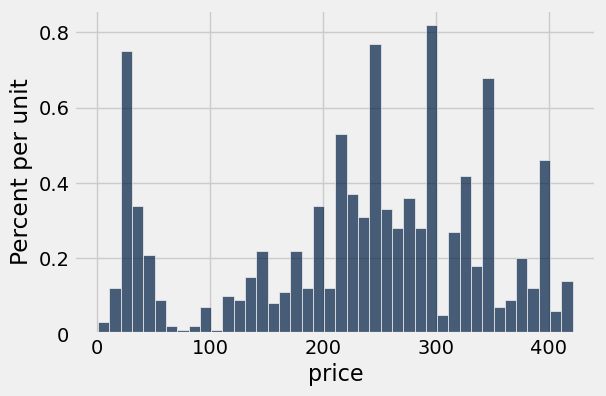

In [31]:
# gets maximum value in the 'price' column
max_price = np.nanmax(real_estate_copy.column('area'))

#gets minimum value in the 'price' column
min_price = np.nanmin(real_estate_copy.column('area'))

real_estate_copy.hist('price', bins = np.arange(min_price, max_price, 10))

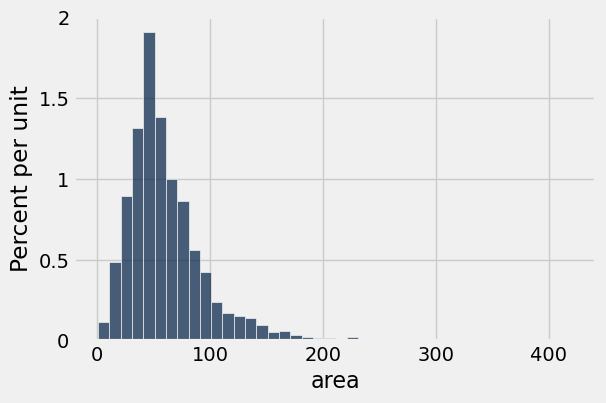

In [32]:
# gets maximum value in the 'area' column
max_area = np.nanmax(real_estate_copy.column('area'))

#gets minimum value in the 'area' column
min_area = np.nanmin(real_estate_copy.column('area'))

real_estate_copy.hist('area', bins = np.arange(min_area, max_area, 10))

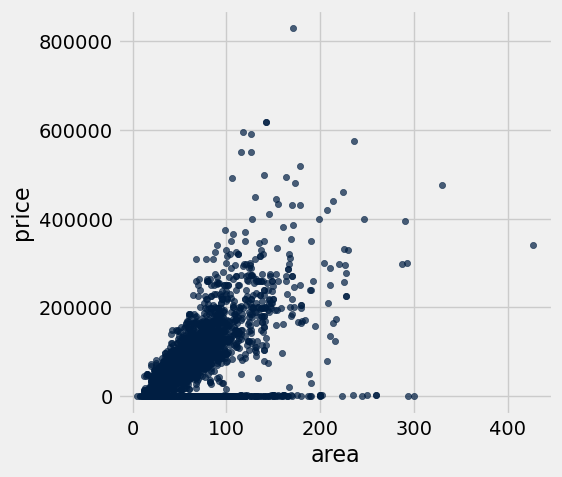

In [33]:
real_estate_copy.scatter('area', 'price')

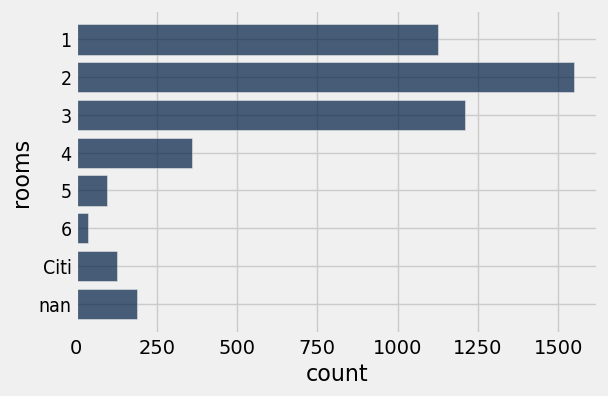

In [34]:
# makes a bar chart for the number of rooms
real_estate_copy.group('rooms').barh('rooms')

### G. Observations

From the scatterplot of area vs price, as the area goes up, we can see that the price goes up too.

From the horizontal bar chart of the number of rooms, most houses have 1-3 rooms.